# Arrival Dynamics 1 — Short-Term Border Arrivals

This notebook shows how observations about a small number of daily refugee arrivals at a border crossing point can be turned into short-term planning forecasts during an unfolding influx situation.

The aim is not to predict a real emergency scenario with all its complexity. The data are synthetic, and the scenario is deliberately simplified. The purpose is to make the forecasting logic visible: what can be estimated from the information available at a given moment, what remains uncertain, and how different modelling assumptions can affect operational preparedness.

In many field settings, short-term planning is driven by simple averages and recent experience. That is often reasonable as a starting point. But mean-based, backward-looking estimates can hide important uncertainty. This notebook shows how the same basic information can be strengthened with simple probabilistic logic: not to produce certainty, but to make uncertainty explicit, quantify plausible ranges, and support better preparedness decisions.

We will follow a 30-day influx episode with synthetically generated data. The full episode exists in the background, but the notebook reveals it step by step. At each decision point, the analysis uses only the observations that would have been available to humanitarian teams at that time.

The scale of arrivals has been deliberately kept low so that the logic is easier to follow. The same ideas can be applied to larger operations; the numbers would change, but the reasoning remains the same.

## Scenario

A conflict escalation in a neighbouring country leads to increasing arrivals over several weeks. We will follow one particular border crossing point. Reception and registration teams need to decide how much capacity to prepare before the full scale of the movement is known.

During the first few days, the available observations suggest that arrivals are rising. But planners do not yet know whether the increase will stabilise, continue gradually, or develop into a larger surge.

## How the analysis is organised

The notebook is organised around decision points.

At each decision point, we will:

1. show the arrival observations available at that moment;
2. make a short-term forecast for the next planning horizon;
3. describe the uncertainty around that forecast;
4. reveal what actually happened only after the forecast has been made;
5. update the planning problem as new information becomes available.

The synthetic dataset contains internal fields used to construct the episode, but those fields are not used as planning information. The analysis works only with the arrival observations that would have been visible to humanitarian teams at the relevant point in time.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt


CANONICAL_RELATIVE_PATH = Path("data/processed/arrival_dynamics_short_term_master.csv")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / CANONICAL_RELATIVE_PATH).exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find the project root from the current working directory.")

src_path = PROJECT_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from forecasting.arrival_dynamics import (  # noqa: E402
    estimate_cautious_arrival_level,
    simulate_cautious_negative_binomial_forecast,
    summarize_preparedness_forecast_totals,
    translate_arrival_totals_to_preparedness,
    estimate_recent_arrival_level,
    mean_baseline_forecast,
    simulate_poisson_forecast,
    simulate_updated_negative_binomial_forecast,
    simulate_updated_poisson_forecast,
    summarize_forecast_totals_by_model,
    summarize_poisson_totals,
)


scenario = pd.read_csv(PROJECT_ROOT / CANONICAL_RELATIVE_PATH)

# Part I — First forecast under limited information

The first decision point occurs after five days of observations. Humanitarian teams need to prepare for the next week, but they do not yet know whether the early increase is temporary or the beginning of a larger movement.

The immediate question is simple:

**Given only the first five days of arrivals, what should planners expect for days 6–12?**

## 1. Initial observations: days 1–5

At the first decision point, only five daily arrival counts are available.

The observed arrivals are:

In [2]:
observed_days_1_5 = scenario.loc[
    scenario["day"].between(1, 5),
    ["day", "arrivals"],
].copy()

observed_days_1_5

,day,arrivals
0,1,25
1,2,40
2,3,44
3,4,48
4,5,69


These first five observations show an early upward signal. Daily arrivals increase from 25 on day 1 to 69 on day 5.

That is enough to raise concern. It is not enough to know the scale of what is coming. The next week could stabilise near the current level, continue increasing gradually, or move into a sharper surge.

At this point, the forecast should be understood as a planning estimate under limited information, not as a confident prediction of the next week.

## 2. A simple point forecast

A natural first step is to use the average of the observations so far.

Using days 1–5, the observed mean is:

In [3]:
observed_mean = observed_days_1_5["arrivals"].mean()
pd.DataFrame(
    {
        "Measure": ["Observed mean arrivals per day"],
        "Value": [observed_mean],
    }
)

,Measure,Value
0,Observed mean arrivals per day,45.2


This gives a simple daily forecast of **45.2 arrivals per day**.

For a seven-day planning horizon, this implies:

In [4]:
baseline_forecast = mean_baseline_forecast(observed_days_1_5)
baseline_total = baseline_forecast["forecast_total_arrivals"].iloc[0]

pd.DataFrame(
    {
        "Forecast start day": [baseline_forecast["day"].min()],
        "Forecast end day": [baseline_forecast["day"].max()],
        "Daily forecast arrivals": [baseline_forecast["forecast_arrivals"].iloc[0]],
        "Forecast horizon days": [baseline_forecast["forecast_horizon_days"].iloc[0]],
        "Forecast total arrivals": [baseline_total],
    }
)

,Forecast start day,Forecast end day,Daily forecast arrivals,Forecast horizon days,Forecast total arrivals
0,6,12,45.2,7,316.4


The deterministic forecast for days 6–12 is therefore **316.4 arrivals** in total.

This is a useful baseline because it is transparent and easy to explain. But it has an important limitation: it gives only one number.

A point forecast does not show how much arrivals might vary around the estimate. It also does not protect against a deeper problem: the early average may stop being a reasonable guide if the underlying arrival level changes.

## 3. Adding uncertainty with a Poisson forecast

The next step is to represent uncertainty around the initial rate estimate.

Here we use a simple Poisson forecast. A Poisson model is often used for count data: situations where we are counting how many events occur in a fixed period. In this case, the “events” are daily arrivals, and the fixed period is one day.

We estimate the daily arrival rate from the first five days. Then, using a few lines of code, we simulate **100,000 possible seven-day futures** for days 6–12. Each simulated future assumes that the early observed rate remains the best available estimate of the daily arrival level.

The daily arrival rate is estimated from the first five days:

In [5]:
poisson_simulations = simulate_poisson_forecast(
    observed_days_1_5,
    n_simulations=100_000,
    seed=20240529,
)

pd.DataFrame(
    {
        "Measure": ["Estimated daily Poisson rate"],
        "Value": [observed_mean],
    }
)

,Measure,Value
0,Estimated daily Poisson rate,45.2


The Poisson simulation keeps the same basic expectation as the point forecast, but it shows how much the seven-day total might vary if the early observed rate remained a reasonable estimate for the next week.

The simulated seven-day totals are summarised below:

In [6]:
poisson_summary = summarize_poisson_totals(
    poisson_simulations,
    percentiles=(5, 25, 50, 75, 90, 95),
)
poisson_summary

,statistic,value
0,mean,316.313680
1,std,17.781681
2,min,247.000000
3,max,391.000000
4,p05,287.000000
5,p25,304.000000
6,p50,316.000000
7,p75,328.000000
8,p90,339.000000
9,p95,346.000000


Under this assumption, the simulated seven-day total is centred around about **316 arrivals**. The 5th to 95th percentile range is approximately **287 to 346 arrivals**.

In other words, if the early observed daily rate remained valid, most simulated futures would produce a seven-day total somewhere in that range. A total near 287 would be relatively low under this assumption, while a total near 346 would be relatively high. The point is not that arrivals will definitely fall inside this range. The point is that the range describes what ordinary random variation looks like under the initial rate assumption.

This is more informative than the point forecast alone. It tells planners that, if the early daily rate remains valid, normal random variation could still lead to somewhat lower or higher totals over the next week.

But the phrase **if the early daily rate remains valid** matters. This forecast represents uncertainty around the initial estimate. It does not account for a rapid change in the underlying arrival level.

## 4. Revealing the first forecast horizon: days 6–12

We now reveal what happened during the first forecast horizon.

The actual arrivals for days 6–12 were:

In [7]:
actual_days_6_12 = scenario.loc[
    scenario["day"].between(6, 12),
    ["day", "arrivals"],
].copy()

actual_days_6_12

,day,arrivals
5,6,96
6,7,106
7,8,101
8,9,83
9,10,136
10,11,188
11,12,148


The actual seven-day total was:

In [8]:
actual_total = actual_days_6_12["arrivals"].sum()
poisson_totals = poisson_simulations.groupby("simulation_id")["simulated_arrivals"].sum()
poisson_p95 = poisson_summary.loc[poisson_summary["statistic"] == "p95", "value"].iloc[0]
exceedance_count = int((poisson_totals >= actual_total).sum())
exceedance_rate = exceedance_count / len(poisson_totals)

forecast_comparison = pd.DataFrame(
    {
        "Measure": [
            "Deterministic baseline total",
            "Actual total",
            "Actual to baseline ratio",
            "Poisson 95th percentile total",
            "Poisson simulations at or above actual",
            "Poisson empirical exceedance rate",
        ],
        "Value": [
            baseline_total,
            actual_total,
            actual_total / baseline_total,
            poisson_p95,
            exceedance_count,
            exceedance_rate,
        ],
    }
)

forecast_comparison

,Measure,Value
0,Deterministic baseline total,316.400000
1,Actual total,858.000000
2,Actual to baseline ratio,2.711757
3,Poisson 95th percentile total,346.000000
4,Poisson simulations at or above actual,0.000000
5,Poisson empirical exceedance rate,0.000000


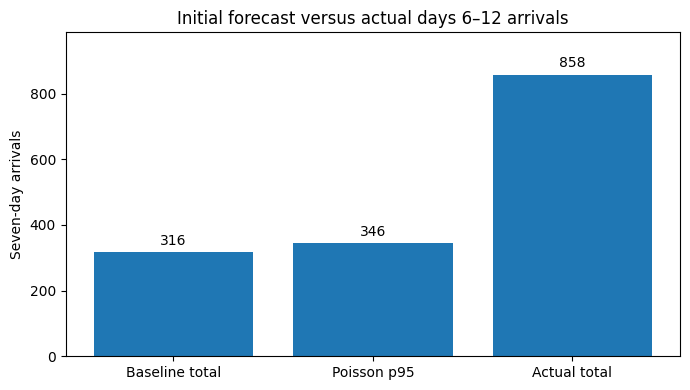

In [9]:
chart_data = pd.DataFrame(
    {
        "forecast_reference": [
            "Baseline total",
            "Poisson p95",
            "Actual total",
        ],
        "arrivals": [baseline_total, poisson_p95, actual_total],
    }
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    chart_data["forecast_reference"],
    chart_data["arrivals"],
)

ax.set_ylabel("Seven-day arrivals")
ax.set_title("Initial forecast versus actual days 6–12 arrivals")
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set_ylim(0, max(chart_data["arrivals"]) * 1.15)

plt.tight_layout()

The result is far outside the initial forecast range.

The deterministic baseline forecast was **316.4 arrivals**. The actual total was **858 arrivals**, about **2.7 times** the baseline. It was also far above the 95th percentile of the initial Poisson forecast.

In the simulation, none of the 100,000 Poisson futures reached a total as high as the actual days 6–12 total.

This does not mean probabilistic forecasting was useless. The Poisson forecast did what it was asked to do: it described uncertainty around the early observed rate.

The problem was that the early observed rate quickly became outdated. After day 5, the arrival level changed sharply. The initial forecast failed mainly because the underlying arrival intensity increased, not because ordinary random fluctuation around the early rate was unusually large.

This distinction matters for the rest of the notebook.

A probabilistic forecast can show uncertainty around a stated assumption. But if the expected arrival level itself is changing, the forecast must be updated as new observations arrive.

At the next decision point, planners have seen days 1–12. The question is no longer whether the first five-day average is enough. The question becomes how to update the expected arrival level, and how much high-demand risk to plan for during the next high-pressure period.

# Part II — Updating the forecast under higher pressure

After days 6–12 are revealed, the planning problem changes.

The first forecast did not fail simply because ordinary random variation was large. It failed mainly because the arrival level moved sharply upward after day 5. The early five-day average was no longer a reasonable guide for the next planning horizon.

At the second decision point, planners have now seen arrivals for days 1–12. The next planning horizon is days 13–18.

The question is no longer:

**What should we expect if the first five days remain a good guide?**

The question is now:

**How should we update the expected arrival level, and how much high-demand risk should we plan for?**

## 5. What changed after the first reveal?

At this point, the visible arrival observations are:

In [10]:
observed_days_1_12 = scenario.loc[
    scenario["day"].between(1, 12),
    ["day", "arrivals"],
].copy()

observed_days_1_12

,day,arrivals
0,1,25
1,2,40
2,3,44
3,4,48
4,5,69
5,6,96
6,7,106
7,8,101
8,9,83
9,10,136


The difference between the first five days and the next seven days is substantial.

In [11]:
period_comparison = pd.DataFrame(
    {
        "Period": ["Days 1–5", "Days 6–12"],
        "Total arrivals": [
            observed_days_1_5["arrivals"].sum(),
            actual_days_6_12["arrivals"].sum(),
        ],
        "Mean daily arrivals": [
            observed_days_1_5["arrivals"].mean(),
            actual_days_6_12["arrivals"].mean(),
        ],
        "Maximum daily arrivals": [
            observed_days_1_5["arrivals"].max(),
            actual_days_6_12["arrivals"].max(),
        ],
    }
)

period_comparison.round(
    {
        "Total arrivals": 1,
        "Mean daily arrivals": 1,
        "Maximum daily arrivals": 1,
    }
)

,Period,Total arrivals,Mean daily arrivals,Maximum daily arrivals
0,Days 1–5,226,45.2,69
1,Days 6–12,858,122.6,188


The first five days had an average of 45.2 arrivals per day. During days 6–12, the average increased to about 122.6 arrivals per day.

This changes the planning picture. The early average was useful as a first reference point, but it should not continue to drive the forecast once the higher arrival level has become visible.

The recent observations also show uneven daily demand. Arrivals during days 6–12 ranged from 83 to 188 arrivals per day. That variation matters because planning is not only about the average number of arrivals. It is also about whether teams can cope with higher-demand days.

## 6. Updating the expected arrival level

For the next forecast, we use the most recent seven days as the update window.

In [12]:
update_window_days_6_12 = scenario.loc[
    scenario["day"].between(6, 12),
    ["day", "arrivals"],
].copy()

update_window_days_6_12

,day,arrivals
5,6,96
6,7,106
7,8,101
8,9,83
9,10,136
10,11,188
11,12,148


This is a simple choice. It gives more weight to the newly observed higher-pressure period and does not average it together with the earlier lower-arrival days.

Using days 6–12, the updated daily arrival level is:

In [13]:
recent_level = estimate_recent_arrival_level(observed_days_1_12)
updated_daily_mean = recent_level.loc[0, "updated_daily_arrival_level"]
recent_daily_std = recent_level.loc[0, "observed_sample_variance"] ** 0.5
recent_daily_cv = recent_level.loc[0, "observed_sample_cv"]

recent_level_table = pd.DataFrame(
    {
        "Measure": [
            "Updated daily mean",
            "Recent daily standard deviation",
            "Recent coefficient of variation",
        ],
        "Value": [updated_daily_mean, recent_daily_std, recent_daily_cv],
    }
)

recent_level_table.assign(
    Value=[
        round(updated_daily_mean, 1),
        round(recent_daily_std, 1),
        round(recent_daily_cv, 3),
    ]
)

,Measure,Value
0,Updated daily mean,122.6
1,Recent daily standard deviation,36.8
2,Recent coefficient of variation,0.3


The updated daily level is about 122.6 arrivals per day.

The recent daily standard deviation is about 36.8 arrivals per day. This means that recent daily arrivals have been quite uneven around the updated average. The coefficient of variation is about 0.30, which is another way of saying that the day-to-day variation is large relative to the average level.

These are not precise long-term estimates. They are planning signals from the information available at this point. The purpose is to update the forecast in a transparent way, while keeping the information boundary clear: days 13–18 are still unknown.

## 7. Comparing two uncertainty assumptions

We now compare two forecasts for days 13–18.

Both forecasts use approximately the same updated daily arrival level: 122.6 arrivals per day.

The difference is how much day-to-day variation they allow around that level.

The first forecast is an updated Poisson forecast. It uses the updated daily mean, but it assumes relatively narrow random variation around that mean.

The second forecast is a Negative Binomial forecast. It keeps the same expected daily level, but allows wider day-to-day variation, using the recent unevenness observed during days 6–12.

Put simply:

- the Poisson forecast asks: what if arrivals fluctuate around the updated level in a relatively narrow way?
- the Negative Binomial forecast asks: what if the next period remains as uneven as the recent observations suggest?

This is not a claim that the Negative Binomial model is the true model. It is a planning assumption used to examine upper-tail risk.

In [14]:
updated_poisson_simulations = simulate_updated_poisson_forecast(
    observed_days_1_12,
    n_simulations=100_000,
    seed=20240529,
)
updated_negative_binomial_simulations = simulate_updated_negative_binomial_forecast(
    observed_days_1_12,
    n_simulations=100_000,
    seed=20240530,
)
updated_forecast_simulations = pd.concat(
    [updated_poisson_simulations, updated_negative_binomial_simulations],
    ignore_index=True,
)

model_assumptions = pd.DataFrame(
    {
        "Model": ["Updated Poisson", "Negative Binomial"],
        "Assumed daily mean": [updated_daily_mean, updated_daily_mean],
        "Assumed daily standard deviation": [
            updated_daily_mean ** 0.5,
            recent_daily_std,
        ],
        "Expected six-day total": [updated_daily_mean * 6, updated_daily_mean * 6],
    }
)

model_assumptions.round(
    {
        "Assumed daily mean": 1,
        "Assumed daily standard deviation": 1,
        "Expected six-day total": 1,
    }
)

,Model,Assumed daily mean,Assumed daily standard deviation,Expected six-day total
0,Updated Poisson,122.6,11.1,735.4
1,Negative Binomial,122.6,36.8,735.4


The two models have almost the same expected six-day total. The difference is the spread.

A Poisson forecast with a daily mean of about 122.6 implies a daily standard deviation of about 11.1 arrivals. The Negative Binomial forecast uses a daily standard deviation closer to the recent observed value, about 36.8 arrivals.

This difference is easier to see in the forecast ranges.

In [15]:
updated_forecast_summary = summarize_forecast_totals_by_model(
    updated_forecast_simulations,
    percentiles=(5, 50, 80, 90, 95),
)
model_labels = {
    "poisson_updated_level": "Updated Poisson",
    "negative_binomial_updated_level": "Negative Binomial",
}
summary_wide = (
    updated_forecast_summary.assign(
        Model=updated_forecast_summary["model"].map(model_labels)
    )
    .pivot(index="Model", columns="statistic", values="value")
    .reset_index()
)
interval_forecast_table = summary_wide[
    ["Model", "p05", "p50", "mean", "p95"]
].rename(
    columns={
        "p05": "5th percentile",
        "p50": "Median",
        "mean": "Mean",
        "p95": "95th percentile",
    }
)
interval_forecast_table = interval_forecast_table.set_index("Model").loc[
    ["Updated Poisson", "Negative Binomial"]
].reset_index()

interval_forecast_table.round(
    {
        "5th percentile": 1,
        "Median": 1,
        "Mean": 1,
        "95th percentile": 1,
    }
)

statistic,Model,5th percentile,Median,Mean,95th percentile
0,Updated Poisson,691.0,735.0,735.3,780.0
1,Negative Binomial,593.0,732.0,735.6,889.0


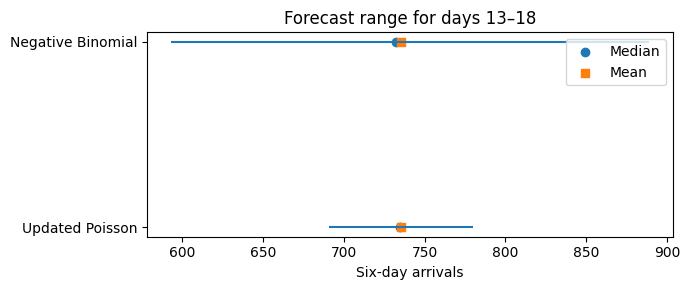

In [16]:
interval_chart_data = interval_forecast_table.copy()
y_positions = range(len(interval_chart_data))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hlines(
    y=list(y_positions),
    xmin=interval_chart_data["5th percentile"],
    xmax=interval_chart_data["95th percentile"],
)
ax.scatter(interval_chart_data["Median"], list(y_positions), label="Median")
ax.scatter(interval_chart_data["Mean"], list(y_positions), marker="s", label="Mean")
ax.set_yticks(list(y_positions), interval_chart_data["Model"])
ax.set_xlabel("Six-day arrivals")
ax.set_title("Forecast range for days 13–18")
ax.legend()

plt.tight_layout()

The centres of the two forecasts are similar. Their ranges are not.

The Negative Binomial forecast has a wider lower tail and a wider upper tail. For preparedness, the upper tail is especially important, because it represents higher-demand outcomes that may strain reception, registration, information provision, and basic assistance capacity.

The upper-tail comparison is:

In [17]:
upper_tail_wide = summary_wide.set_index("Model")
upper_tail_comparison = pd.DataFrame(
    {
        "Percentile": ["80th percentile", "90th percentile", "95th percentile"],
        "Poisson total": [
            upper_tail_wide.loc["Updated Poisson", "p80"],
            upper_tail_wide.loc["Updated Poisson", "p90"],
            upper_tail_wide.loc["Updated Poisson", "p95"],
        ],
        "Negative Binomial total": [
            upper_tail_wide.loc["Negative Binomial", "p80"],
            upper_tail_wide.loc["Negative Binomial", "p90"],
            upper_tail_wide.loc["Negative Binomial", "p95"],
        ],
    }
)
upper_tail_comparison["Difference"] = (
    upper_tail_comparison["Negative Binomial total"]
    - upper_tail_comparison["Poisson total"]
)
upper_tail_comparison["NB / Poisson"] = (
    upper_tail_comparison["Negative Binomial total"]
    / upper_tail_comparison["Poisson total"]
)

upper_tail_comparison.round(
    {
        "Poisson total": 1,
        "Negative Binomial total": 1,
        "Difference": 1,
        "NB / Poisson": 3,
    }
)

,Percentile,Poisson total,Negative Binomial total,Difference,NB / Poisson
0,80th percentile,758.0,810.0,52.0,1.069
1,90th percentile,770.0,853.0,83.0,1.108
2,95th percentile,780.0,889.0,109.0,1.140


At the 95th percentile, the Negative Binomial forecast is about 109 arrivals higher than the Poisson forecast over the six-day horizon.

That difference is operationally meaningful. It does not change the expected number of arrivals very much. It changes what planners might consider a high but plausible demand level.

## 8. Revealing the high-pressure period: days 13–18

We now reveal what happened during the next forecast horizon.

The actual arrivals for days 13–18 were:

In [18]:
actual_days_13_18 = scenario.loc[
    scenario["day"].between(13, 18),
    ["day", "arrivals"],
].copy()

actual_days_13_18

,day,arrivals
12,13,151
13,14,234
14,15,167
15,16,193
16,17,164
17,18,137


The actual six-day total was:

In [19]:
actual_total_13_18 = actual_days_13_18["arrivals"].sum()
updated_forecast_totals = (
    updated_forecast_simulations.groupby(["model", "simulation_id"])[
        "simulated_arrivals"
    ]
    .sum()
    .reset_index(name="simulated_total_arrivals")
)

actual_comparison_rows = []
for model_key, model_label in model_labels.items():
    model_totals = updated_forecast_totals.loc[
        updated_forecast_totals["model"] == model_key,
        "simulated_total_arrivals",
    ]
    model_summary = upper_tail_wide.loc[model_label]
    median_total = model_summary["p50"]
    p95_total = model_summary["p95"]
    actual_comparison_rows.append(
        {
            "Model": model_label,
            "Median": median_total,
            "95th percentile": p95_total,
            "Actual total": actual_total_13_18,
            "Actual / median": actual_total_13_18 / median_total,
            "Actual / 95th percentile": actual_total_13_18 / p95_total,
            "Empirical exceedance probability": (
                model_totals >= actual_total_13_18
            ).mean(),
        }
    )

actual_comparison = pd.DataFrame(actual_comparison_rows)
actual_comparison.round(
    {
        "Median": 1,
        "95th percentile": 1,
        "Actual total": 1,
        "Actual / median": 3,
        "Actual / 95th percentile": 3,
        "Empirical exceedance probability": 3,
    }
)

,Model,Median,95th percentile,Actual total,Actual / median,Actual / 95th percentile,Empirical exceedance probability
0,Updated Poisson,735.0,780.0,1046,1.423,1.341,0.000
1,Negative Binomial,732.0,889.0,1046,1.429,1.177,0.001


The realised total was 1046 arrivals.

That is above the 95th percentile of both forecasts. It is also well above the forecast medians.

This result should be interpreted carefully.

The Negative Binomial forecast gave a wider upper tail than the Poisson forecast. It would have led to more cautious planning for high-demand outcomes. But it still did not fully capture the realised high-pressure total.

That does not make the comparison useless. It shows two things at once.

First, allowing for wider variability can materially change preparedness quantities. At the same expected level, the Negative Binomial forecast gave a much higher 95th percentile than the Poisson forecast.

Second, no single forecast made at one decision point removes the need for continued monitoring and updating. The situation is still developing, and the expected arrival level may continue to shift.

The lesson is not that one model is “true” and the other is “false.” The lesson is that model assumptions matter. A forecast is always conditional on what is known at the time and on the assumptions used to represent uncertainty.

The next step is to connect these forecast differences to operational planning. A difference of 100 or more arrivals in the upper tail may sound abstract, but it becomes more concrete when translated into reception pressure and overcrowding, registration workload and risk of backlog, or staffing and assistance needs.

# Part III — Updating, Preparedness and Operational Backlog Risk

The previous section showed that the high-pressure period exceeded both forecast ranges. That does not mean the forecasting exercise was useless. It means the forecast has to be updated again.

At this point, the notebook shifts from asking only **what might arrive next** to asking **what those possible arrivals imply for immediate operational preparedness**.

In a real operation, preparedness would not wait until this point. It would already have begun after the first arrivals were observed. For the purposes of this demonstration, however, we focus on preparedness here so that the logic is easier to follow. The same ideas can be applied earlier in the scenario as well.

The operational question now becomes sharper:

**How much response capacity should be prepared before the next period is revealed?**

In this part, we first translate updated forecasts into immediate preparedness quantities. Then we move from total preparedness quantities to the more difficult question of daily throughput and unresolved backlog.

## 9. Updating after the high-pressure period

At this decision point, planners have seen arrivals through day 18.

In [20]:
actual_days_13_18 = scenario.loc[
    scenario["day"].between(13, 18),
    ["day", "arrivals"],
].copy()

actual_days_13_18


,day,arrivals
12,13,151
13,14,234
14,15,167
15,16,193
16,17,164
17,18,137


The most recent observations are still high, but they are also uneven. This makes it risky to assume that pressure has immediately stabilised.

We now use days 13–18 as the update window and forecast the next five days: days 19–23.

In [21]:
cautious_level_13_18 = estimate_cautious_arrival_level(
    scenario,
    observed_start_day=13,
    observed_end_day=18,
)

cautious_level_13_18_display = cautious_level_13_18.rename(
    columns={
        "updated_daily_arrival_level": "Updated daily mean",
        "recent_sample_sd": "Recent sample SD",
        "sd_floor": "SD floor",
        "assumed_daily_sd": "Assumed daily SD",
    }
)[
    [
        "Updated daily mean",
        "Recent sample SD",
        "SD floor",
        "Assumed daily SD",
    ]
]

cautious_level_13_18_display.round(1)


,Updated daily mean,Recent sample SD,SD floor,Assumed daily SD
0,174.3,34.7,43.6,43.6


The updated daily level is about **174.3 arrivals per day**.

The recent sample standard deviation is about **34.7 arrivals per day**. The cautious standard-deviation floor is slightly higher, about **43.6 arrivals per day**, so the forecast keeps a wider uncertainty range rather than assuming that volatility has already disappeared.

This is a preparedness choice. It is deliberately cautious after a volatile high-pressure period.

In [22]:
forecast_days_19_23_simulations = simulate_cautious_negative_binomial_forecast(
    scenario,
    observed_start_day=13,
    observed_end_day=18,
    forecast_start_day=19,
    forecast_end_day=23,
    n_simulations=100_000,
    seed=20240531,
)

forecast_days_19_23_totals = summarize_preparedness_forecast_totals(
    forecast_days_19_23_simulations,
    percentiles=(50, 80, 95),
)

forecast_days_19_23_summary = forecast_days_19_23_totals.rename(
    columns={
        "forecast_reference": "Forecast reference",
        "forecast_total_arrivals": "Forecast total arrivals",
    }
)[["Forecast reference", "Forecast total arrivals"]]

forecast_days_19_23_summary.round({"Forecast total arrivals": 1})


,Forecast reference,Forecast total arrivals
0,p50,869.0
1,p80,953.0
2,p95,1038.0


The forecast gives a typical five-day total of about **869 arrivals**, with a high-end preparedness reference around **1,038 arrivals** at the 95th percentile.

These totals can be translated into immediate preparedness quantities.

The following assumptions are illustrative. They are not universal humanitarian standards. They are used here to show how arrival forecasts can be converted into operational planning quantities. In a real response, preparedness assumptions would depend on applicable standards, the local context, available resources, and the intended response model.

In [23]:
preparedness_assumptions = pd.DataFrame(
    {
        "Planning quantity": [
            "Immediate water",
            "Immediate food",
            "Protection/information contact",
            "Protection contact capacity",
            "Medical readiness",
            "Registration workload",
        ],
        "Illustrative assumption": [
            "3 litres per arrival",
            "1 food unit per arrival",
            "1 brief contact per arrival",
            "60 contacts per staff-day",
            "minimum 1 medical team; add 1 team per 250 average daily arrivals",
            "1 registration per arrival",
        ],
    }
)

preparedness_assumptions


,Planning quantity,Illustrative assumption
0,Immediate water,3 litres per arrival
1,Immediate food,1 food unit per arrival
2,Protection/information contact,1 brief contact per arrival
3,Protection contact capacity,60 contacts per staff-day
4,Medical readiness,minimum 1 medical team; add 1 team per 250 ave...
5,Registration workload,1 registration per arrival


Using these assumptions, the forecast translates into the following immediate preparedness quantities.

In [24]:
preparedness_days_19_23 = translate_arrival_totals_to_preparedness(
    forecast_days_19_23_totals,
    forecast_horizon_days=5,
)

preparedness_days_19_23_display = preparedness_days_19_23.rename(
    columns={
        "forecast_reference": "Forecast reference",
        "forecast_total_arrivals": "Forecast total arrivals",
        "average_daily_arrivals": "Average daily arrivals",
        "immediate_water_litres": "Immediate water litres",
        "immediate_food_units": "Immediate food units",
        "protection_contacts": "Protection contacts",
        "protection_staff_days": "Protection staff-days",
        "registration_workload": "Registration workload",
        "medical_team_days": "Medical team-days",
    }
)[
    [
        "Forecast reference",
        "Forecast total arrivals",
        "Average daily arrivals",
        "Immediate water litres",
        "Immediate food units",
        "Protection contacts",
        "Protection staff-days",
        "Registration workload",
        "Medical team-days",
    ]
]

preparedness_days_19_23_display.round(
    {
        "Forecast total arrivals": 1,
        "Average daily arrivals": 1,
        "Immediate water litres": 1,
        "Immediate food units": 1,
        "Protection contacts": 1,
        "Registration workload": 1,
    }
)


,Forecast reference,Forecast total arrivals,Average daily arrivals,Immediate water litres,Immediate food units,Protection contacts,Protection staff-days,Registration workload,Medical team-days
0,p50,869.0,173.8,2607.0,869.0,869.0,15,869.0,5
1,p80,953.0,190.6,2859.0,953.0,953.0,16,953.0,5
2,p95,1038.0,207.6,3114.0,1038.0,1038.0,18,1038.0,5


This table makes the operational effect of forecast uncertainty visible. Planning around the median is not the same as planning around the upper tail. The difference becomes water, food, protection and information-provision workload, registration workload, and medical team readiness.

We now reveal what actually happened during days 19–23.

In [25]:
actual_days_19_23 = scenario.loc[
    scenario["day"].between(19, 23),
    ["day", "arrivals"],
].copy()

actual_days_19_23


,day,arrivals
18,19,163
19,20,126
20,21,121
21,22,150
22,23,120


In [26]:
actual_total_19_23 = int(actual_days_19_23["arrivals"].sum())
assert actual_total_19_23 == 680

actual_days_19_23_comparison = forecast_days_19_23_summary.copy()
actual_days_19_23_comparison["Actual total"] = actual_total_19_23
actual_days_19_23_comparison["Actual minus forecast"] = (
    actual_days_19_23_comparison["Actual total"]
    - actual_days_19_23_comparison["Forecast total arrivals"]
)
actual_days_19_23_comparison["Actual / forecast"] = (
    actual_days_19_23_comparison["Actual total"]
    / actual_days_19_23_comparison["Forecast total arrivals"]
)

actual_days_19_23_comparison.round(
    {
        "Forecast total arrivals": 1,
        "Actual total": 1,
        "Actual minus forecast": 1,
        "Actual / forecast": 3,
    }
)


,Forecast reference,Forecast total arrivals,Actual total,Actual minus forecast,Actual / forecast
0,p50,869.0,680,-189.0,0.783
1,p80,953.0,680,-273.0,0.714
2,p95,1038.0,680,-358.0,0.655


The actual total for days 19–23 was **680 arrivals**.

That is below the cautious forecast median. In hindsight, the immediate post-surge forecast was conservative.

This is not a reason to discard the forecast logic. It shows the trade-off in preparedness planning. Immediately after a volatile high-pressure period, a cautious forecast may overstate the next few days if the situation begins to moderate. But the alternative risk is more serious: relaxing too quickly and under-preparing while pressure remains high.

The lesson is that forecast updates are not only technical adjustments. They express an operational posture toward uncertainty.

## 10. Planning for partial stabilisation

After days 19–23 are revealed, the planning picture changes again.

The recent observations are lower than the high-pressure period, but they are not low. The operation is still receiving substantial daily arrivals.

At this point, planners have seen arrivals through day 23. The final planning horizon is days 24–30.

In [27]:
actual_days_19_23


,day,arrivals
18,19,163
19,20,126
20,21,121
21,22,150
22,23,120


We now use days 19–23 as the update window and forecast days 24–30.

In [28]:
cautious_level_19_23 = estimate_cautious_arrival_level(
    scenario,
    observed_start_day=19,
    observed_end_day=23,
)

cautious_level_19_23_display = cautious_level_19_23.rename(
    columns={
        "updated_daily_arrival_level": "Updated daily mean",
        "recent_sample_sd": "Recent sample SD",
        "sd_floor": "SD floor",
        "assumed_daily_sd": "Assumed daily SD",
    }
)[
    [
        "Updated daily mean",
        "Recent sample SD",
        "SD floor",
        "Assumed daily SD",
    ]
]

cautious_level_19_23_display.round(1)


,Updated daily mean,Recent sample SD,SD floor,Assumed daily SD
0,136.0,19.4,34.0,34.0


The updated daily level is about **136.0 arrivals per day**.

The recent sample standard deviation is about **19.4 arrivals per day**. The cautious standard-deviation floor is **34.0 arrivals per day**, so the forecast again avoids assuming that uncertainty has collapsed just because the most recent window looks calmer.

In [29]:
forecast_days_24_30_simulations = simulate_cautious_negative_binomial_forecast(
    scenario,
    observed_start_day=19,
    observed_end_day=23,
    forecast_start_day=24,
    forecast_end_day=30,
    n_simulations=100_000,
    seed=20240601,
)

forecast_days_24_30_totals = summarize_preparedness_forecast_totals(
    forecast_days_24_30_simulations,
    percentiles=(50, 80, 95),
)

forecast_days_24_30_summary = forecast_days_24_30_totals.rename(
    columns={
        "forecast_reference": "Forecast reference",
        "forecast_total_arrivals": "Forecast total arrivals",
    }
)[["Forecast reference", "Forecast total arrivals"]]

forecast_days_24_30_summary.round({"Forecast total arrivals": 1})


,Forecast reference,Forecast total arrivals
0,p50,949.0
1,p80,1026.0
2,p95,1105.0


The typical seven-day forecast is about **949 arrivals**, with a 95th percentile preparedness reference of about **1,105 arrivals**.

Using the same immediate preparedness assumptions, this becomes:

In [30]:
preparedness_days_24_30 = translate_arrival_totals_to_preparedness(
    forecast_days_24_30_totals,
    forecast_horizon_days=7,
)

preparedness_days_24_30_display = preparedness_days_24_30.rename(
    columns={
        "forecast_reference": "Forecast reference",
        "forecast_total_arrivals": "Forecast total arrivals",
        "average_daily_arrivals": "Average daily arrivals",
        "immediate_water_litres": "Immediate water litres",
        "immediate_food_units": "Immediate food units",
        "protection_contacts": "Protection contacts",
        "protection_staff_days": "Protection staff-days",
        "registration_workload": "Registration workload",
        "medical_team_days": "Medical team-days",
    }
)[
    [
        "Forecast reference",
        "Forecast total arrivals",
        "Average daily arrivals",
        "Immediate water litres",
        "Immediate food units",
        "Protection contacts",
        "Protection staff-days",
        "Registration workload",
        "Medical team-days",
    ]
]

preparedness_days_24_30_display.round(
    {
        "Forecast total arrivals": 1,
        "Average daily arrivals": 1,
        "Immediate water litres": 1,
        "Immediate food units": 1,
        "Protection contacts": 1,
        "Registration workload": 1,
    }
)


,Forecast reference,Forecast total arrivals,Average daily arrivals,Immediate water litres,Immediate food units,Protection contacts,Protection staff-days,Registration workload,Medical team-days
0,p50,949.0,135.6,2847.0,949.0,949.0,16,949.0,7
1,p80,1026.0,146.6,3078.0,1026.0,1026.0,18,1026.0,7
2,p95,1105.0,157.9,3315.0,1105.0,1105.0,19,1105.0,7


This is useful, but it is still incomplete.

A total-arrival forecast can tell us the scale of response to prepare. It can estimate water, food, protection and information-provision workload, medical readiness, and registration workload over the whole horizon.

But it does not yet answer the operational question that matters most for the next step:

**Can the team process arrivals day by day without unresolved cases accumulating?**

That depends on timing and capacity. A seven-day total may look manageable on average, while daily peaks still create backlog. The next section therefore turns the forecast into a registration-capacity problem.